In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob
from collections import defaultdict
import matplotlib.collections as mcoll
import scipy.stats as stats
import numpyro
import numpyro.distributions as dist
from jax import random
import corner
import arviz as az
import jax.numpy as jnp

/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.1245031364648869


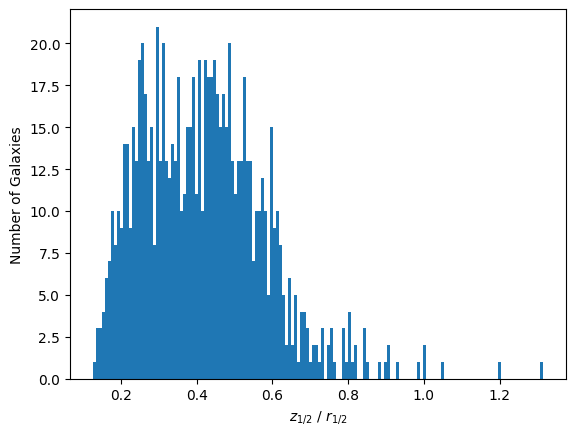

565


In [11]:
csv_dataframe = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv', float_precision='round_trip')

#Plot histogram for z_1/2 / r_1/2 values for first 15 galaxies

ratios = np.array(csv_dataframe['ratio'])

mask = (~np.isnan(ratios)) & (ratios > 0.05)
ratios = ratios[mask]
print(min(ratios))

Chosen_galaxies = np.array(csv_dataframe['Gal_number'])[mask]

plt.hist(ratios, bins=150) 
plt.xlabel('$z_{1/2}$ / $r_{1/2}$')
plt.ylabel('Number of Galaxies')
plt.show()

h1_specific_angular_mom = np.array(csv_dataframe['h1_specific_angular_mom'])
h1_specific_angular_mom = h1_specific_angular_mom[mask]

error_gals = []
for i in range(len(h1_specific_angular_mom)):
    if isinstance(h1_specific_angular_mom[i], float):
        error_gals.append(Chosen_galaxies[i])


manual_check = [128, 162, 575, 185, 1048, 849, 545, 498, 458, 329, 583, 10, 141]

for x in manual_check:
    if x in Chosen_galaxies:
        Chosen_galaxies = Chosen_galaxies[Chosen_galaxies != x]

for x in error_gals:
    if x in Chosen_galaxies:
        Chosen_galaxies = Chosen_galaxies[Chosen_galaxies != x]

print(len(Chosen_galaxies))
np.savetxt('Chosen_galaxies.txt', Chosen_galaxies, delimiter=',')

1080
873
Number of Chosen Galaxies is 216


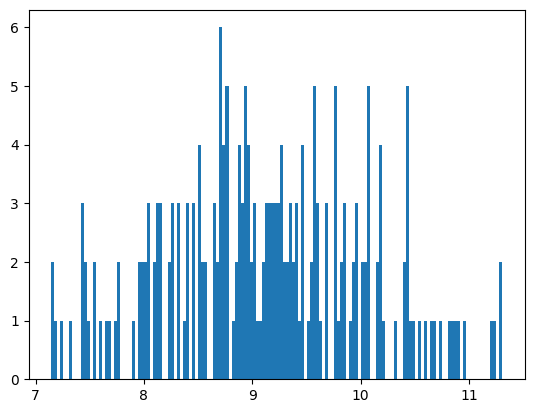

In [3]:
#Now running for all galaxies

csv_dataframe = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv', float_precision='round_trip')

galaxies = np.array(csv_dataframe['Gal_number'])

ratios = np.array(csv_dataframe['ratio'])

masses = np.array(csv_dataframe['mass'])

print(len(galaxies))

galaxies = galaxies[~np.isnan(ratios)]
masses = masses[~np.isnan(ratios)]
ratios = ratios[~np.isnan(ratios)]

galaxies = galaxies[ratios > 0.01]
masses = masses[ratios > 0.01]
ratios = ratios[ratios > 0.01]

print(len(galaxies))

#Chosen galaxies are ones with a ratio of less that 0.3 and with masses > 10^7Msun
Chosen_galaxies = galaxies[(ratios < 0.3) & (masses > 10**7)]

print('Number of Chosen Galaxies is', len(Chosen_galaxies))



masses = masses[(ratios < 0.3) & (masses > 10**7)]

plt.hist(np.log10(masses), bins=150, histtype = 'stepfilled')
plt.show()


In [4]:

print(Chosen_galaxies)
np.savetxt('Chosen_galaxies.txt', Chosen_galaxies, delimiter=',')


[   1    2    7    8    9   10   11   12   13   14   16   18   19   20
   21   22   23   24   25   27   29   31   34   36   37   38   39   41
   47   49   50   51   52   53   54   57   58   61   64   65   66   69
   71   72   74   77   80   83   84   86   89   90   92   95   96  100
  102  106  107  108  110  112  113  114  116  117  120  123  124  128
  132  134  137  141  143  144  147  148  149  152  155  156  159  161
  162  165  166  168  169  170  177  179  182  184  185  187  188  189
  191  193  197  198  200  212  220  228  233  241  243  246  247  253
  255  256  258  259  260  261  262  280  290  312  322  328  329  339
  352  355  362  375  378  379  382  383  387  388  391  395  396  397
  399  407  413  427  430  433  439  456  458  467  475  478  480  488
  493  494  496  498  499  504  508  516  535  539  545  547  561  563
  570  575  583  594  598  608  610  617  619  622  628  629  657  660
  664  666  685  687  693  697  713  752  758  768  779  793  804  825
  849 

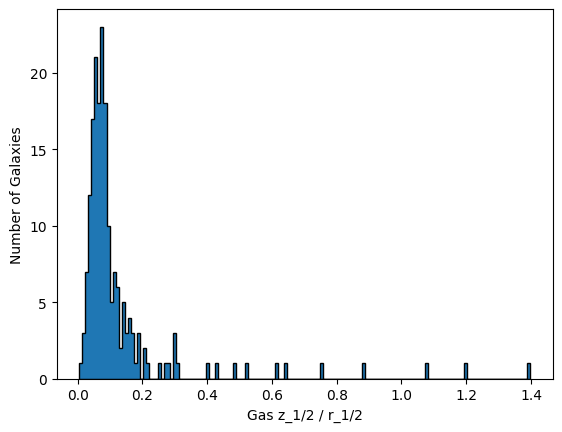

Number of Chosen Galaxies is 172
Chosen Galaxies are [   1    2    7    8    9   10   11   12   13   14   16   18   20   21
   22   23   25   27   31   34   36   38   47   49   50   51   52   53
   54   57   61   64   66   69   71   72   74   77   80   83   89   95
   96  100  102  106  107  108  110  112  113  114  117  120  123  124
  128  132  134  137  141  143  147  149  152  155  156  159  161  165
  166  169  177  179  182  184  185  187  188  189  191  193  197  198
  200  220  228  233  241  243  246  247  253  255  256  258  259  260
  261  280  290  312  322  328  329  339  352  362  375  378  379  382
  383  387  388  391  395  396  407  413  427  430  433  439  458  475
  478  480  488  493  494  498  499  504  508  516  535  539  545  547
  561  563  570  583  594  598  608  610  617  619  628  629  657  693
  697  713  752  758  779  804  849  924  943  945  964  968  999 1011
 1014 1045 1048 1075]


In [5]:
galaxy_dataframe = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv', float_precision='round_trip')

galaxies_number = np.array(galaxy_dataframe['Gal_number'])
r_half = np.array(galaxy_dataframe['r_half'])
z_half = np.array(galaxy_dataframe['z_half'])
gas_r_half = np.array(galaxy_dataframe['gas_r_half'])
gas_z_half = np.array(galaxy_dataframe['gas_z_half'])
gas_ratio = np.array(galaxy_dataframe['gas_ratio'])

new_chosen_galaxies = []

for gal in Chosen_galaxies:

    r_half = gas_r_half[galaxies_number == gal]
    if r_half == 0:
        continue

    else:
        new_chosen_galaxies.append(int(gal))

Chosen_galaxies = new_chosen_galaxies
Chosen_galaxies = np.array(Chosen_galaxies)

gas_ratio = gas_ratio[Chosen_galaxies-1]


plt.hist(gas_ratio, bins = 150, histtype = 'stepfilled', edgecolor='black')
plt.xlabel('Gas z_1/2 / r_1/2')
plt.ylabel('Number of Galaxies')
plt.show()

mask = gas_ratio < 0.25

Chosen_galaxies = Chosen_galaxies[mask]

print('Number of Chosen Galaxies is', len(Chosen_galaxies))
np.savetxt('Chosen_galaxies.txt', Chosen_galaxies, delimiter=',')

print('Chosen Galaxies are', Chosen_galaxies)

In [6]:


deffo_mergers = [128, 162, 575, 594]

for x in deffo_mergers:
    if x in Chosen_galaxies:
        Chosen_galaxies = Chosen_galaxies[Chosen_galaxies != x]

manual_check = [128, 162, 575, 185, 1048, 849, 545, 498, 458, 329, 583, 10, 141]

for x in manual_check:
    if x in Chosen_galaxies:
        Chosen_galaxies = Chosen_galaxies[Chosen_galaxies != x]

n_within_ten_perc_r_vir = [375, 427, 241, 413, 47, 49, 14]

for x in n_within_ten_perc_r_vir:
    if x in Chosen_galaxies:
        Chosen_galaxies = Chosen_galaxies[Chosen_galaxies != x]

print('Number of Chosen Galaxies is', len(Chosen_galaxies))
np.savetxt('Chosen_galaxies.txt', Chosen_galaxies, delimiter=',')
print('Chosen Galaxies are', Chosen_galaxies)


        

Number of Chosen Galaxies is 153
Chosen Galaxies are [   1    2    7    8    9   11   12   13   16   18   20   21   22   23
   25   27   31   34   36   38   50   51   52   53   54   57   61   64
   66   69   71   72   74   77   80   83   89   95   96  100  102  106
  107  108  110  112  113  114  117  120  123  124  132  134  137  143
  147  149  152  155  156  159  161  165  166  169  177  179  182  184
  187  188  189  191  193  197  198  200  220  228  233  243  246  247
  253  255  256  258  259  260  261  280  290  312  322  328  339  352
  362  378  379  382  383  387  388  391  395  396  407  430  433  439
  475  478  480  488  493  494  499  504  508  516  535  539  547  561
  563  570  598  608  610  617  619  628  629  657  693  697  713  752
  758  779  804  924  943  945  964  968  999 1011 1014 1045 1075]


In [12]:
#PYTREEGRAV RESULTS

directory = '/mnt/users/darnej/MPhys/pytree_results'

files = glob.glob(directory + '/*.csv')

pytree_results = defaultdict(list)

for i in Chosen_galaxies:
    file = directory + '/pytree_results_' + str(i) + '.csv'
    gal_number = int(i)
    csv = pd.read_csv(file, float_precision='round_trip')
    a_r = np.array(csv['mean_a_r_py'])
    a_tot = np.array(csv['mean_a_r_total_py'])
    mean_r = np.array(csv['mean_r'])
    pytree_results[gal_number] = [a_r, a_tot, mean_r]




1270
1270
1270
1270


/tmp/ipykernel_3817757/2122492289.py:69: RuntimeWarning: divide by zero encountered in log10
  points = np.array([np.log10(pytree_results[key][0]), np.log10(pytree_results[key][1])]).T.reshape(-1, 1, 2)


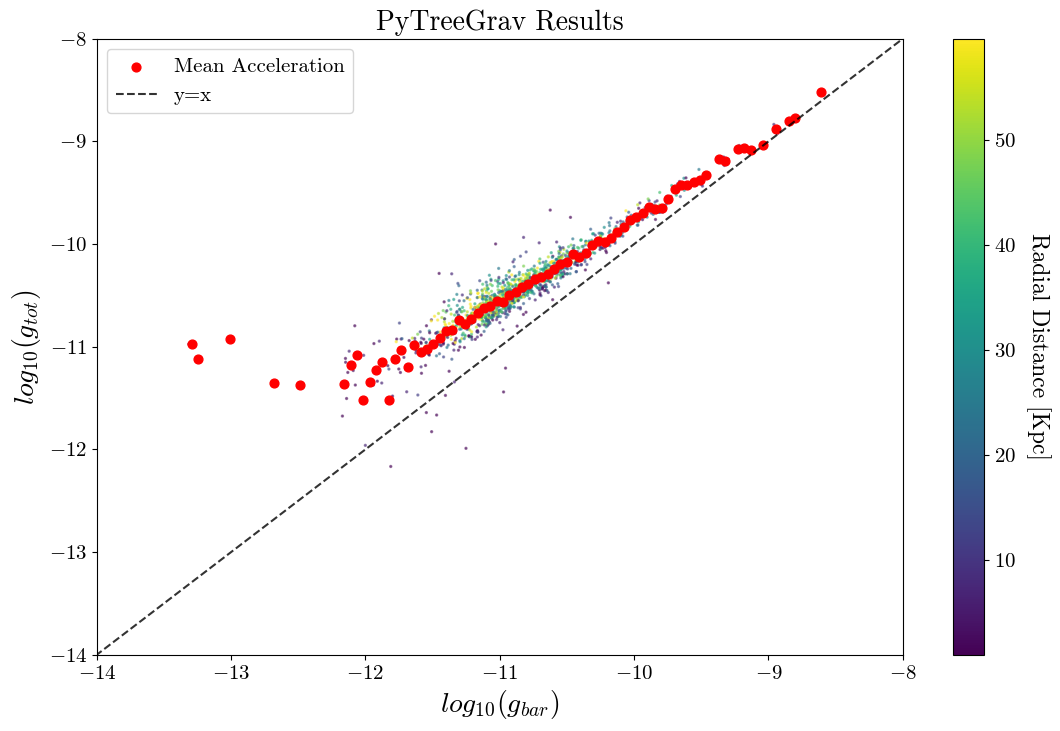

In [13]:
#PLOTTING PYTREEGRAV RESULTS
fig = plt.figure(figsize=(13, 8))

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size


g_tot_all_tree = []
g_bar_all_tree = []

for gal in pytree_results:
    gal_num_ind = galaxies_number == gal
    g_tot = pytree_results[gal][1]
    g_bar = pytree_results[gal][0]
    mean_r = pytree_results[gal][2]

    r_half = gas_r_half[gal_num_ind][0]
    
    r_over_r_half = mean_r / r_half

    #MASK TO SAY HOW MANY MULTIPLES OF GAS_R_HALF YOU WANT TO GO OUT TO 

    r_mask = (r_over_r_half <= 5) & (r_over_r_half >= 0.2)

    g_tot = g_tot[r_mask]
    g_bar = g_bar[r_mask]
    mean_r = mean_r[r_mask]



    plt.scatter(np.log10(g_bar), np.log10(g_tot), s = 2, alpha = 0.5, c = mean_r)

    g_tot_all_tree = g_tot_all_tree + list(g_tot)
    g_bar_all_tree = g_bar_all_tree + list(g_bar)


g_tot_all_tree = np.array(g_tot_all_tree)
g_bar_all_tree = np.array(g_bar_all_tree)

print(len(g_tot_all_tree))
print(len(g_bar_all_tree))

mask = g_bar_all_tree > 0
g_tot_all_tree = g_tot_all_tree[mask]
g_bar_all_tree = g_bar_all_tree[mask]

print(len(g_tot_all_tree))
print(len(g_bar_all_tree))

mean, bins, bin_number = stats.binned_statistic(np.log10(g_bar_all_tree), np.log10(g_tot_all_tree), bins=100, statistic='mean')

bincenters = 0.5*(bins[1:]+bins[:-1])

plt.scatter(bincenters, mean, label = 'Mean Acceleration', color = 'red', s = 40)
#plt.plot(bincenters, mean, color = 'red', linewidth = 4)



x = np.linspace(-16, -8, 100)
y = x
plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.8, label = 'y=x')


key = list(pytree_results.keys())[0]
colors = pytree_results[key][2]
points = np.array([np.log10(pytree_results[key][0]), np.log10(pytree_results[key][1])]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(np.array(colors).min(), np.array(colors).max())
lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
lc.set_array(colors)

cbar = fig.colorbar(lc, ax = plt.gca())
cbar.set_label("Radial Distance [Kpc]", rotation=270, labelpad=25, fontsize = 17)



plt.xlabel('$log_{10}(g_{bar})$', fontsize = 20)
plt.ylabel('$log_{10}(g_{tot})$', fontsize = 20)
plt.legend(prop={'size': 15})
plt.xlim(-14,-8)
plt.title('PyTreeGrav Results', fontsize = 20)
plt.ylim(-14,-8)

plt.show()

sample: 100%|██████████| 2500/2500 [00:05<00:00, 468.04it/s, 3 steps of size 1.07e+00. acc. prob=0.85]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.60      0.01      0.60      0.59      0.62   2048.62      1.00
     sigma      0.12      0.00      0.12      0.12      0.13   2007.62      1.00

Number of divergences: 0


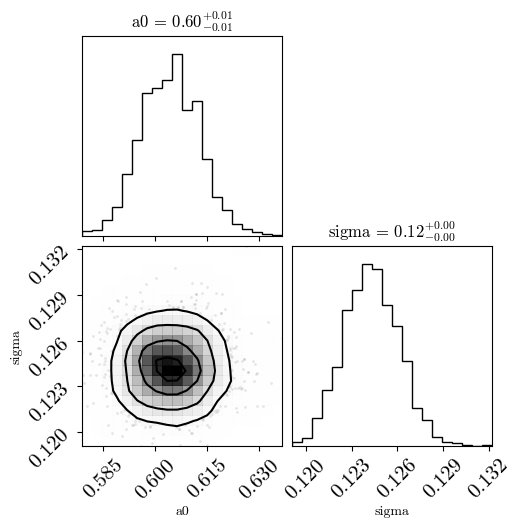

In [9]:
gbar, gtot = g_bar_all_tree, g_tot_all_tree


log_gbar = jnp.log10(gbar)
log_gtot = jnp.log10(gtot)


def model(x=None, y=None):

    a0 = numpyro.sample("a0", dist.Uniform(0, 5))
    sigma = numpyro.sample("sigma", dist.Uniform(0, 5))
    shape = 1
    
    # Prediction of y
    log_gtot_pred = jnp.log10(gbar*(1-jnp.exp(-(gbar/(a0*1e-10))**(shape/2)))**(-1/shape))  

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(log_gtot_pred, sigma), obs=log_gtot)

# Run MCMC
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=2000)
mcmc.run(rng_key_, x=gbar, y=log_gtot)

mcmc.print_summary()
samples = mcmc.get_samples()
res = az.from_numpyro(mcmc)

# Extract posterior samples as a NumPy array
samples_array = np.array([res.posterior[var].values.flatten() for var in res.posterior.keys()]).T


# Corner plot
fig = corner.corner(
    samples_array,
    labels=list(res.posterior.keys()),  # Ensure correct variable names
    show_titles=True,
    smooth = 1,
)
plt.show()

a0: 0.6044035
sigma: 0.12427087


/tmp/ipykernel_1471932/1205004169.py:30: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(g_bar_individual), np.log10(g_tot), alpha = 0.5, c = mean_r, s = 2)


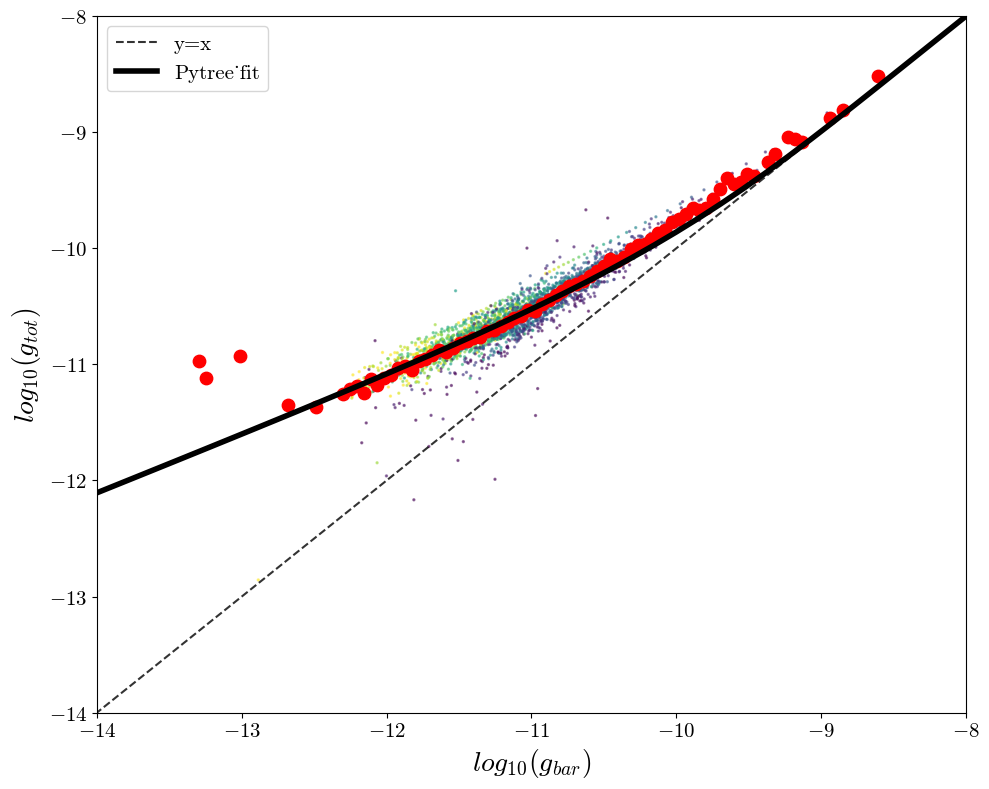

In [10]:
a0 = np.median(samples_array[:, 0])
sigma_pytree = np.median(samples_array[:, 1])

print('a0:', a0)
shape = 1
print('sigma:', sigma_pytree)

g_bar = np.logspace(-8, -14, 40)

log_g_tot_pred_pytree = np.log10(g_bar*(1-np.exp(-(g_bar/(a0*1e-10))**(shape/2)))**(-1/shape))

plt.figure(figsize=(10,8))

x = np.linspace(-15, -8, 100)
y = x
plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.8, label = 'y=x')

for gal in pytree_results:
    g_tot = pytree_results[gal][1]
    g_bar_individual = pytree_results[gal][0]
    mean_r = pytree_results[gal][2]



    g_tot = g_tot[r_mask]
    g_bar_individual = g_bar_individual[r_mask]
    mean_r = mean_r[r_mask]


    plt.scatter(np.log10(g_bar_individual), np.log10(g_tot), alpha = 0.5, c = mean_r, s = 2)


#plt.scatter(np.log10(g_bar), log_g_tot_pred_pytree, color='black', label='Pytree_fit', s=80)
plt.plot(np.log10(g_bar), log_g_tot_pred_pytree, color='black', label='Pytree_fit', linewidth=4)


#plt.plot(bincenters, mean, color = 'red', linewidth = 4)
plt.scatter(bincenters, mean, color = 'red', s = 80)



#plt.scatter(bincenters, mean, color='red', label='Mean Acceleration', alpha = 0.8, marker = 'D')
plt.xlabel('$log_{10}(g_{bar})$', fontsize = 20)
plt.ylabel('$log_{10}(g_{tot})$', fontsize = 20)
plt.xlim(-14, -8)
plt.ylim(-14, -8)
plt.legend(prop = {'size': 15})
plt.tight_layout()
plt.show()

In [11]:
#Plotting RAR for all Galaxies

rar = defaultdict(list)

directory = '/mnt/users/darnej/MPhys/RAR_for_all/'

files = glob.glob(os.path.join(directory, '*.csv'))

files.sort()

g_bar_all = []
g_obs_all = []
g_tot_all = []
mean_r_all = []



for i in Chosen_galaxies:
    file = directory + '/results_for_' + str(i) + '.csv'
    csv = pd.read_csv(file, float_precision='round_trip')
    mean_acc_bar = csv['mean_acc_bar']
    mean_acc_obs = csv['mean_acc_obs']
    mean_r = csv['mean_r']
    total_mean_acc_bar = csv['total_mean_acc_bar']
    gal_number = int(i)


    mean_acc_bar = mean_acc_bar[r_mask]
    mean_acc_obs = mean_acc_obs[r_mask]
    total_mean_acc_bar = total_mean_acc_bar[r_mask]
    mean_r = mean_r[r_mask]

    g_bar_all = g_bar_all + list(mean_acc_bar)
    g_obs_all = g_obs_all + list(mean_acc_obs)
    g_tot_all = g_tot_all + list(total_mean_acc_bar)
    mean_r_all = mean_r_all + list(mean_r)



    rar[gal_number] = [mean_acc_bar, mean_acc_obs, mean_r, total_mean_acc_bar, r_over_r_half]


g_tot_all = np.array(g_tot_all)
g_bar_all = np.array(g_bar_all)
g_obs_all = np.array(g_obs_all)
mean_r_all = np.array(mean_r_all)


#The g bar values contains some 0's therefore we need to remove them to not get -inf when take log 10

print(len(g_bar_all))
print(len(g_obs_all))
print(len(g_tot_all))



g_tot_all = g_tot_all[g_bar_all > 0]
mean_r_all = mean_r_all[g_bar_all > 0]
g_obs_all = g_obs_all[g_bar_all > 0]
g_bar_all = g_bar_all[g_bar_all > 0]



print(len(g_bar_all))
print(len(g_obs_all))
print(len(g_tot_all))


#Creating mean

mean_rar, bins_rar, bin_number = stats.binned_statistic(np.log10(g_bar_all), np.log10(g_obs_all), bins=100, statistic='mean')

bincenters_rar = 0.5*(bins_rar[1:]+bins_rar[:-1])

mean_tot, bins_tot, bin_number = stats.binned_statistic(np.log10(g_bar_all), np.log10(g_tot_all), bins=100, statistic='mean')

bincenters_tot = 0.5*(bins_tot[1:]+bins_tot[:-1])




4350
4350
4350
2038
2038
2038


150


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


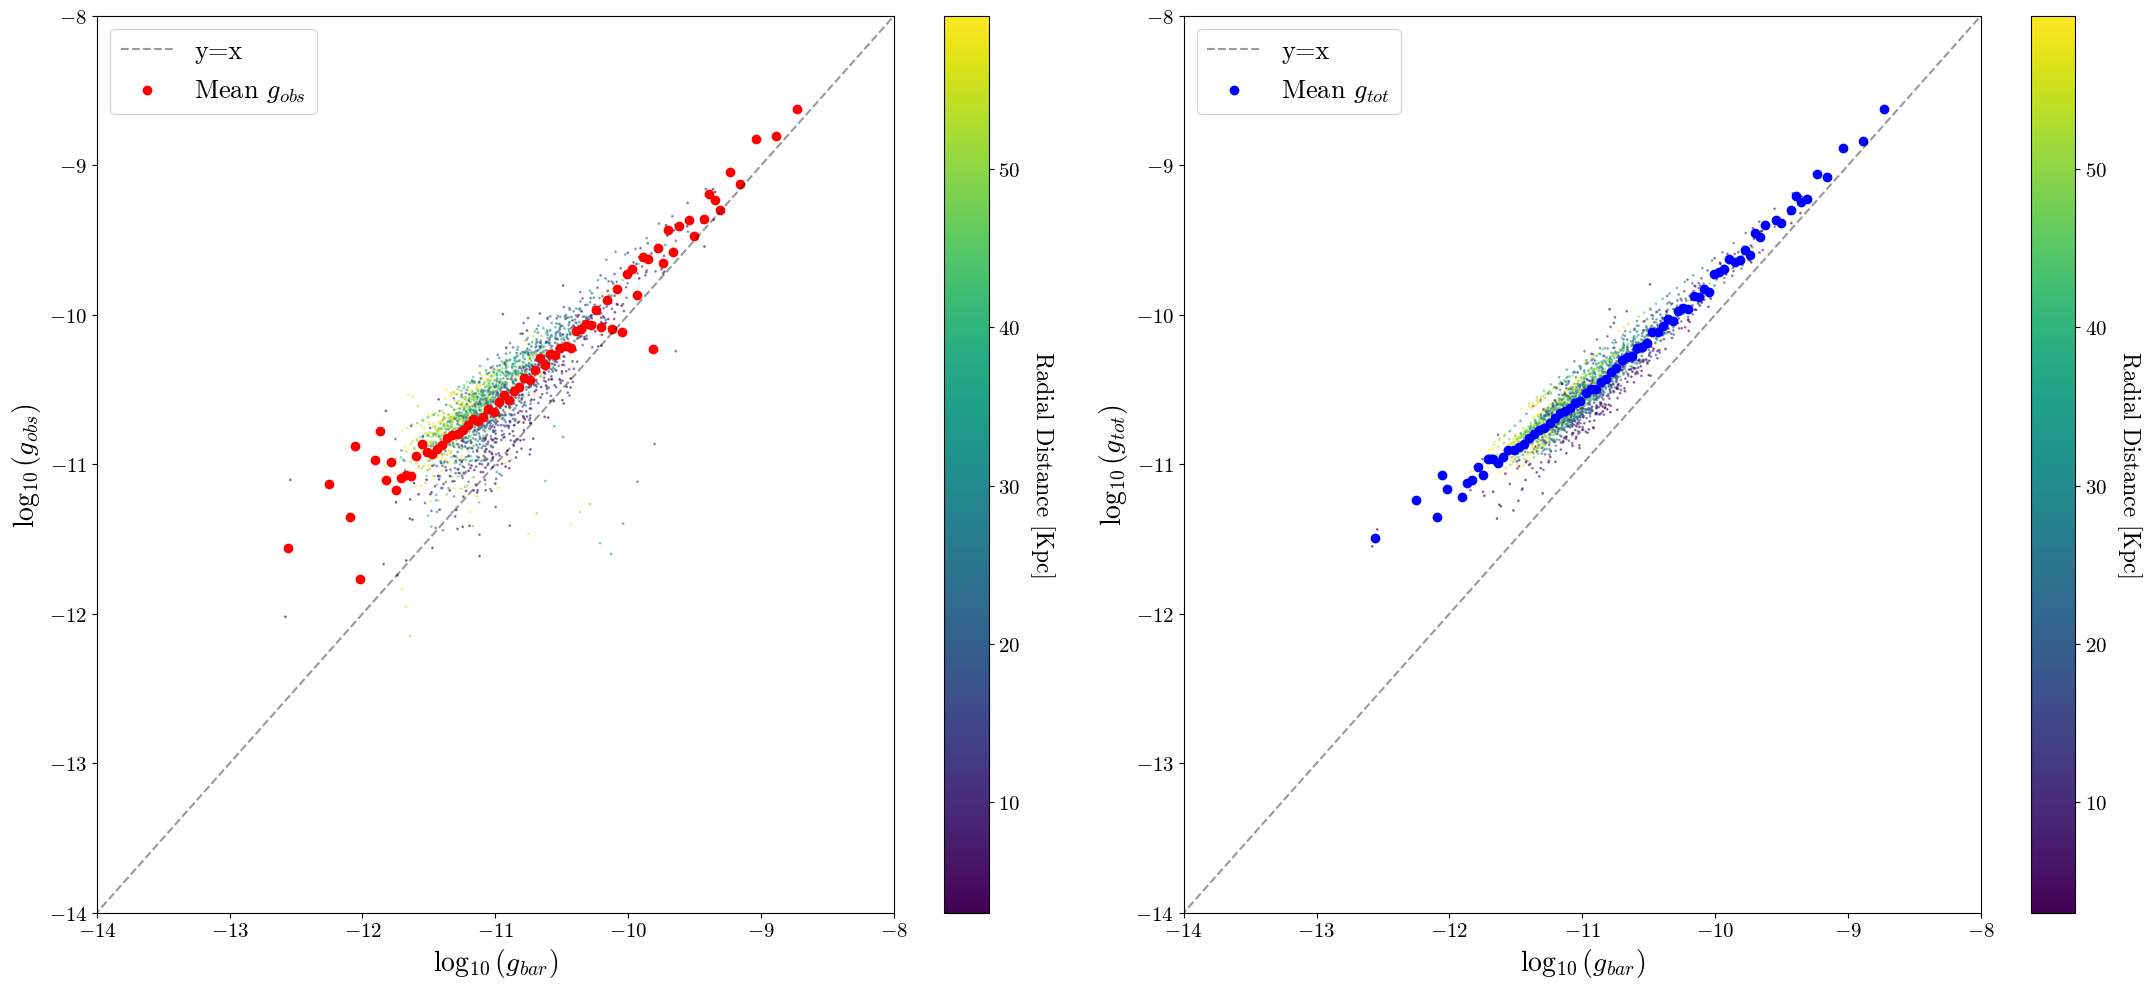

In [12]:
print(len(rar))

fig, ax = plt.subplots(1, 2, figsize = (22,10))
#fig.suptitle('RAR for all galaxies', fontsize = 30)

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size




for gal in rar:

    g_bar = rar[gal][0]
    g_obs = rar[gal][1]

    ax[0].scatter(np.log10(g_bar), np.log10(g_obs), s = 1, alpha = 0.5, c = rar[gal][2])

    g_bar = rar[gal][0]
    g_tot = rar[gal][3]

    ax[1].scatter(np.log10(g_bar), np.log10(g_tot), s = 1, alpha = 0.5, c = rar[gal][2])

x = np.linspace(-16, -8, 100)
y = x
ax[0].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4, label = 'y=x')
ax[1].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4, label = 'y=x')  


#ax[0].plot(bincenters_rar, mean_rar, label = 'Mean $g_{obs}$', color = 'red', linewidth = 4)
ax[0].scatter(bincenters_rar, mean_rar, label = 'Mean $g_{obs}$', color = 'red')



ax[0].set_xlabel('$\log_{10}({g_{bar}})$', fontsize = 20)
ax[0].set_ylabel('$\log_{10}({g_{obs}})$', fontsize = 20)
ax[0].set_xlim(-14, -8)
ax[0].set_ylim(-14,-8)


#ax[1].plot(bincenters_tot, mean_tot, color = 'blue', label = 'Mean $g_{tot}$', linewidth = 4)
ax[1].scatter(bincenters_tot, mean_tot, color = 'blue', label = 'Mean $g_{tot}$')


ax[1].set_xlabel('$\log_{10}({g_{bar}})$', fontsize = 20)
ax[1].set_ylabel('$\log_{10}({g_{tot}})$', fontsize = 20)
ax[1].set_xlim(-14, -8)
ax[1].set_ylim(-14,-8)


colors = rar[key][2]
points = np.array([np.log10(rar[key][0]), np.log10(rar[key][1])]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(np.array(colors).min(), np.array(colors).max())
lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
lc.set_array(colors)

cbar = fig.colorbar(lc, ax = ax[1])
cbar.set_label("Radial Distance [Kpc]", rotation=270, labelpad=25, fontsize = 17)

cbar = fig.colorbar(lc, ax = ax[0])
cbar.set_label("Radial Distance [Kpc]", rotation=270, labelpad=25, fontsize = 17)


actual_g_bar = np.linspace(1e-8, 1e-14, 100)
actual_g_obs = actual_g_bar/2 + np.sqrt((actual_g_bar**2)/4 + actual_g_bar*1.6e-10)

actual_g_tot = actual_g_bar/(1-np.exp(-np.sqrt(actual_g_bar/1.2e-10)))

#ax[0].plot(np.log10(actual_g_bar), np.log10(actual_g_obs), label = 'Theoretical', color = 'black')
#ax[1].plot(np.log10(actual_g_bar), np.log10(actual_g_tot), label = 'Theoretical', color = 'black')

ax[0].legend(prop={'size': 19})
ax[1].legend(prop={'size': 19})
plt.tight_layout()
plt.show()

sample: 100%|██████████| 2500/2500 [00:04<00:00, 526.47it/s, 3 steps of size 9.39e-01. acc. prob=0.90]  



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.39      0.01      0.39      0.37      0.40   1982.33      1.00
     sigma      0.21      0.00      0.21      0.20      0.21   1804.75      1.00

Number of divergences: 0


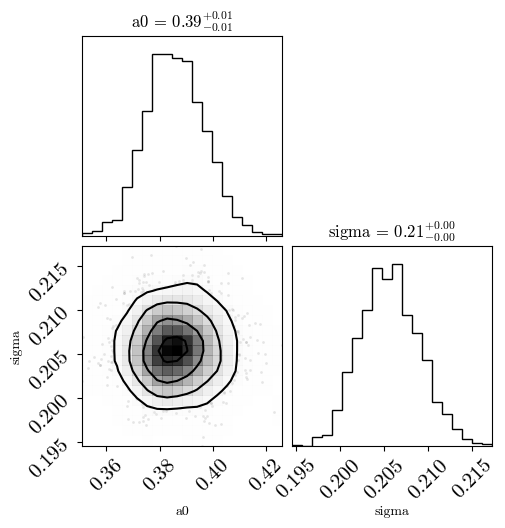

In [13]:


gbar, gobs = g_bar_all, g_obs_all


log_gbar = jnp.log10(gbar)
log_gobs = jnp.log10(gobs)


def model(x=None, y=None):

    a0 = numpyro.sample("a0", dist.Uniform(0, 5))
    sigma = numpyro.sample("sigma", dist.Uniform(0, 5))
    shape = 1
    
    # Prediction of y
    log_gobs_pred = jnp.log10(gbar*(1-jnp.exp(-(gbar/(a0*1e-10))**(shape/2)))**(-1/shape))   # Add RAR formula

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(log_gobs_pred, sigma), obs=log_gobs)

# Run MCMC
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=2000)
mcmc.run(rng_key_, x=gbar, y=log_gobs)

mcmc.print_summary()
samples = mcmc.get_samples()
res = az.from_numpyro(mcmc)

# Extract posterior samples as a NumPy array
samples_array_obs = np.array([res.posterior[var].values.flatten() for var in res.posterior.keys()]).T


# Corner plot
fig = corner.corner(
    samples_array_obs,
    labels=list(res.posterior.keys()),  # Ensure correct variable names
    show_titles=True,
    smooth = 1,
)
plt.show()

a0: 0.38565207
shape: 1
sigma: 0.20557684


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


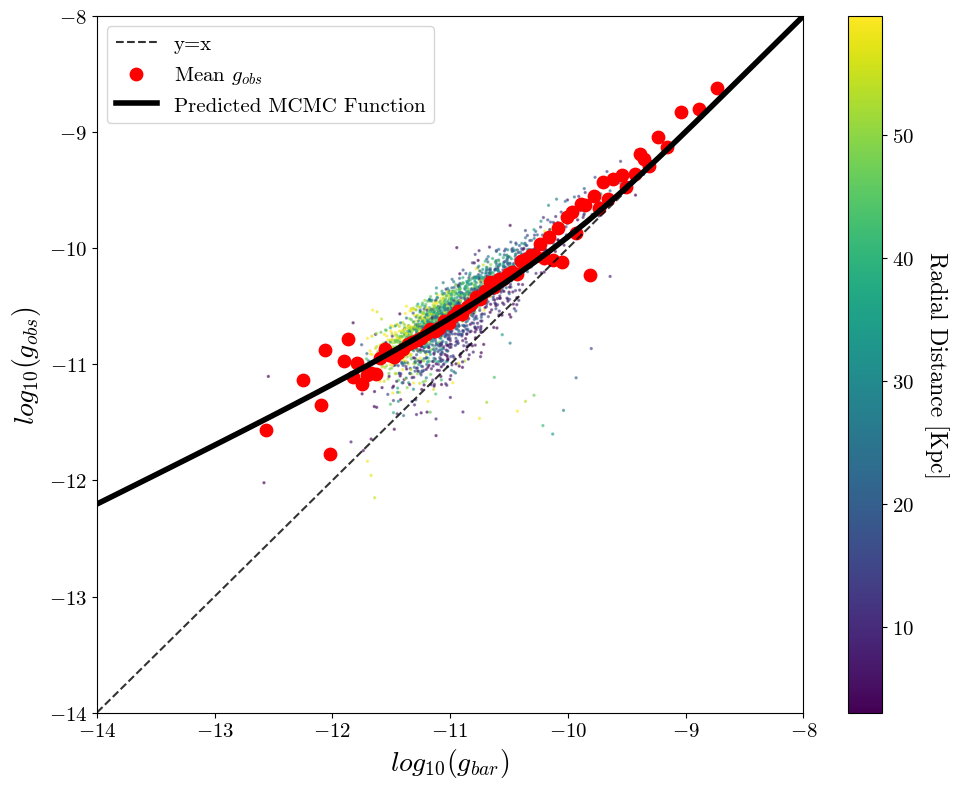

In [14]:

a0 = np.median(samples_array_obs[:, 0])
shape = 1
sigma_obs = np.median(samples_array_obs[:, 1])

print('a0:', a0)
print('shape:', shape)
print('sigma:', sigma_obs)

g_bar = np.logspace(-8, -14, 40)

log_g_obs_pred = np.log10(g_bar*(1-np.exp(-(g_bar/(a0*1e-10))**(shape/2)))**(-1/shape))  



plt.figure(figsize=(10,8))

x = np.linspace(-15, -8, 100)
y = x



for gal in rar:
    g_obs = rar[gal][1]
    g_bar_individual = rar[gal][0]
    mean_r = rar[gal][2]

    plt.scatter(np.log10(g_bar_individual), np.log10(g_obs), alpha = 0.5, c = mean_r, s = 2)

plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.8, label = 'y=x')

#plt.plot(bincenters_rar, mean_rar, color = 'red', linewidth = 4, label = 'Mean $g_{obs}$')
plt.scatter(bincenters_rar, mean_rar, color = 'red', s = 80, label = 'Mean $g_{obs}$')

#plt.scatter(np.log10(g_bar), log_g_obs_pred, color='black', label='Predicted MCMC Function', s = 80)
plt.plot(np.log10(g_bar), log_g_obs_pred, color='black', label='Predicted MCMC Function', linewidth = 4)

key = list(rar.keys())[0]
colors = rar[key][2]
points = np.array([np.log10(rar[key][0]), np.log10(rar[key][1])]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(np.array(colors).min(), np.array(colors).max())
lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
lc.set_array(colors)

cbar = fig.colorbar(lc, ax = plt.gca())
cbar.set_label("Radial Distance [Kpc]", rotation=270, labelpad=25, fontsize = 17)



plt.xlabel('$log_{10}(g_{bar})$', fontsize = 20)
plt.ylabel('$log_{10}(g_{obs})$', fontsize = 20)
plt.xlim(-14, -8)
plt.ylim(-14, -8)
plt.legend(prop = {'size': 15})
plt.tight_layout()
plt.show()

sample: 100%|██████████| 2500/2500 [00:04<00:00, 536.13it/s, 3 steps of size 9.89e-01. acc. prob=0.89]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.53      0.01      0.53      0.51      0.54   2007.58      1.00
     sigma      0.11      0.00      0.11      0.11      0.12   2028.24      1.00

Number of divergences: 0


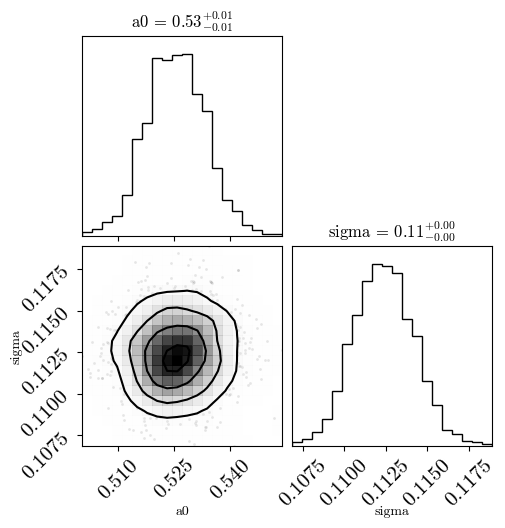

In [15]:
gbar, gtot = g_bar_all, g_tot_all

log_gbar = jnp.log10(gbar)
log_gtot = jnp.log10(gtot)


def model(x=None, y=None):

    a0 = numpyro.sample("a0", dist.Uniform(0, 5))
    sigma = numpyro.sample("sigma", dist.Uniform(0, 5))
    shape = 1
    
    # Prediction of y
    log_gtot_pred = jnp.log10(gbar*(1-jnp.exp(-(gbar/(a0*1e-10))**(shape/2)))**(-1/shape))   # Add RAR formula

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(log_gtot_pred, sigma), obs=log_gtot)

# Run MCMC
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=2000)
mcmc.run(rng_key_, x=gbar, y=log_gtot)

mcmc.print_summary()
samples = mcmc.get_samples()
res = az.from_numpyro(mcmc)

# Extract posterior samples as a NumPy array
samples_array_tot = np.array([res.posterior[var].values.flatten() for var in res.posterior.keys()]).T


# Corner plot
fig = corner.corner(
    samples_array_tot,
    labels=list(res.posterior.keys()),  # Ensure correct variable names
    show_titles=True,
    smooth = 1
)
plt.show()

/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


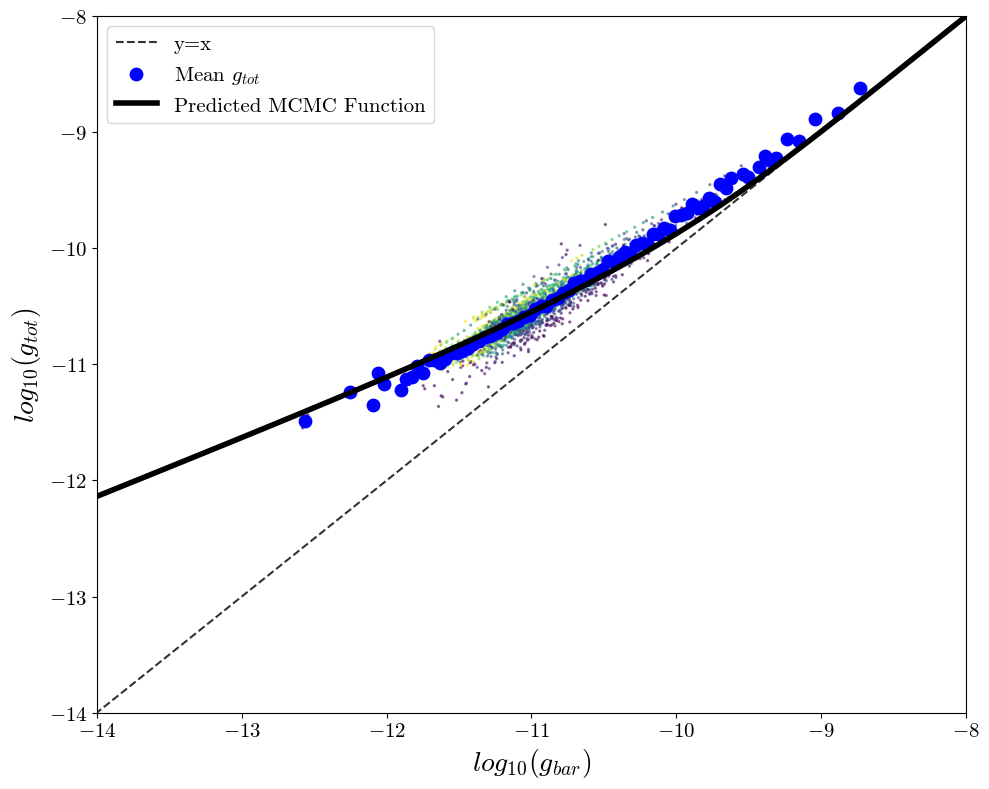

In [16]:

a0 = np.median(samples_array_tot[:, 0])
shape = 1
sigma_tot = np.median(samples_array_tot[:, 1])

g_bar = np.logspace(-8, -14, 40)

log_g_tot_pred = np.log10(g_bar*(1-np.exp(-(g_bar/(a0*1e-10))**(shape/2)))**(-1/shape))  

plt.figure(figsize=(10,8))


x = np.linspace(-15, -8, 100)
y = x
plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.8, label = 'y=x')



for gal in rar:
    g_tot = rar[gal][3]
    g_bar_individual = rar[gal][0]
    mean_r = rar[gal][2]

    plt.scatter(np.log10(g_bar_individual), np.log10(g_tot), alpha = 0.5, c = mean_r, s = 2)

#plt.plot(bincenters_tot, mean_tot, color = 'blue', linewidth = 4, label = 'Mean $g_{tot}$')
plt.scatter(bincenters_tot, mean_tot, color = 'blue', s = 80, label = 'Mean $g_{tot}$')


#plt.scatter(np.log10(g_bar), log_g_tot_pred, color='black', label='Predicted MCMC Function', s = 80)
plt.plot(np.log10(g_bar), log_g_tot_pred, color='black', label='Predicted MCMC Function', linewidth = 4)


plt.xlabel('$log_{10}(g_{bar})$', fontsize = 20)
plt.ylabel('$log_{10}(g_{tot})$', fontsize = 20)
plt.xlim(-14, -8)
plt.ylim(-14, -8)
plt.legend(prop = {'size': 15})
plt.tight_layout()
plt.show()

150


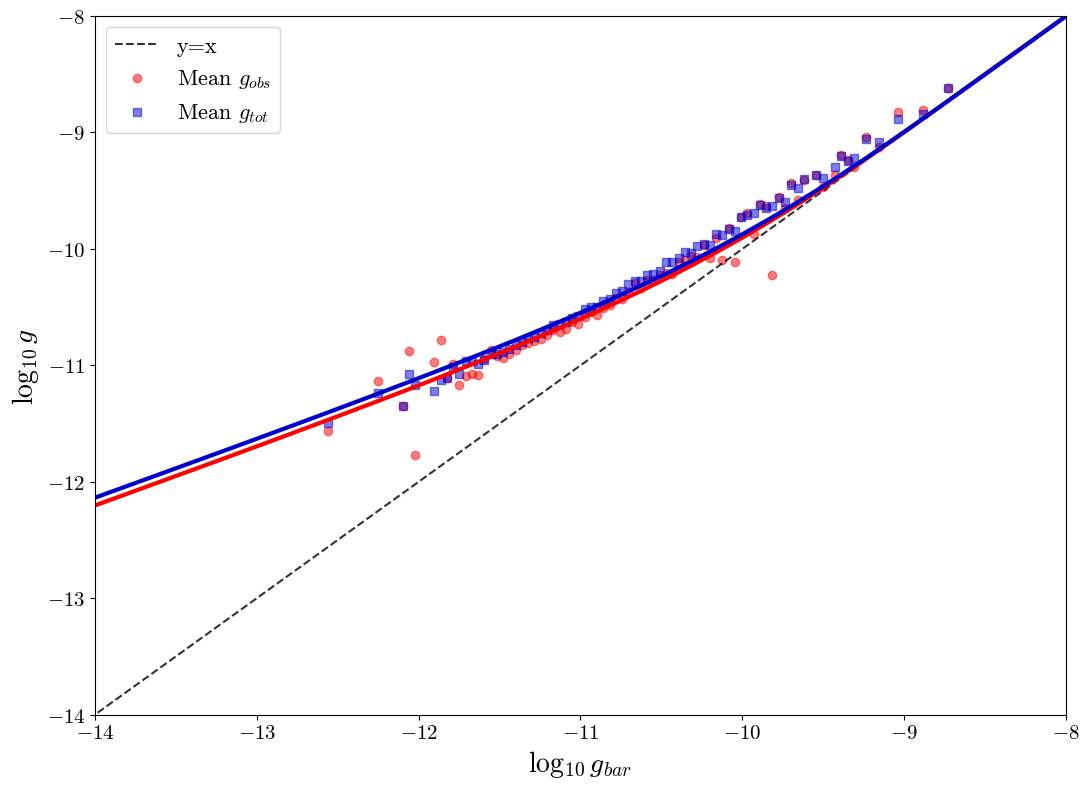

In [17]:
print(len(rar))

fig, ax = plt.subplots(figsize = (11,8))


plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size




# for gal in rar:

#     g_bar = rar[gal][0]
#     g_obs = rar[gal][1]

#     plt.scatter(np.log10(g_bar), np.log10(g_obs), s = 1, alpha = 0.3, c = rar[gal][2])

#     g_bar = rar[gal][0]
#     g_tot = rar[gal][3]

#     plt.scatter(np.log10(g_bar), np.log10(g_tot), s = 1, alpha = 0.3, c = rar[gal][2])


x = np.linspace(-16, -8, 100)
y = x
plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.8, label = 'y=x') 

g_bar = np.logspace(-8, -14, 40)

plt.scatter(bincenters_rar, mean_rar, label = 'Mean $g_{obs}$', color = 'red', alpha = 0.5)
plt.plot(np.log10(g_bar), log_g_obs_pred, color='red', linewidth = 3)


plt.xlabel('$\log_{10}{g_{bar}}$', fontsize = 20)
plt.ylabel('$\log_{10}{g}$', fontsize = 20)
plt.xlim(-14, -8)
plt.ylim(-14,-8)


plt.scatter(bincenters_tot, mean_tot, color = 'mediumblue', label = 'Mean $g_{tot}$', alpha = 0.5, marker = ',')
plt.plot(np.log10(g_bar), log_g_tot_pred, color='mediumblue', linewidth = 3)


# colors = rar[1][2]
# points = np.array([np.log10(rar[1][0]), np.log10(rar[1][1])]).T.reshape(-1, 1, 2)
# segments = np.concatenate([points[:-1], points[1:]], axis=1)
# norm = plt.Normalize(np.array(colors).min(), np.array(colors).max())
# lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
# lc.set_array(colors)

# cbar = fig.colorbar(lc, ax=ax)
# cbar.set_label("Radial Distance [Kpc]", rotation=270, labelpad=25, fontsize = 15)


SPARC_csv = pd.read_csv('/mnt/users/darnej/MPhys/SPARC_RAR.csv', float_precision='round_trip')

SPARC_g_bar = np.array(SPARC_csv.iloc[:, 0])
SPARC_g_obs = np.array(SPARC_csv.iloc[:, 1])
SPARC_std = np.array(SPARC_csv.iloc[:, 2])

#plt.errorbar(SPARC_g_bar, SPARC_g_obs, yerr = SPARC_std, fmt = 'o', color = 'black', label = 'SPARC Data', ms = 8)


plt.legend(prop={'size': 16})
plt.tight_layout()
plt.show()



2544
2038


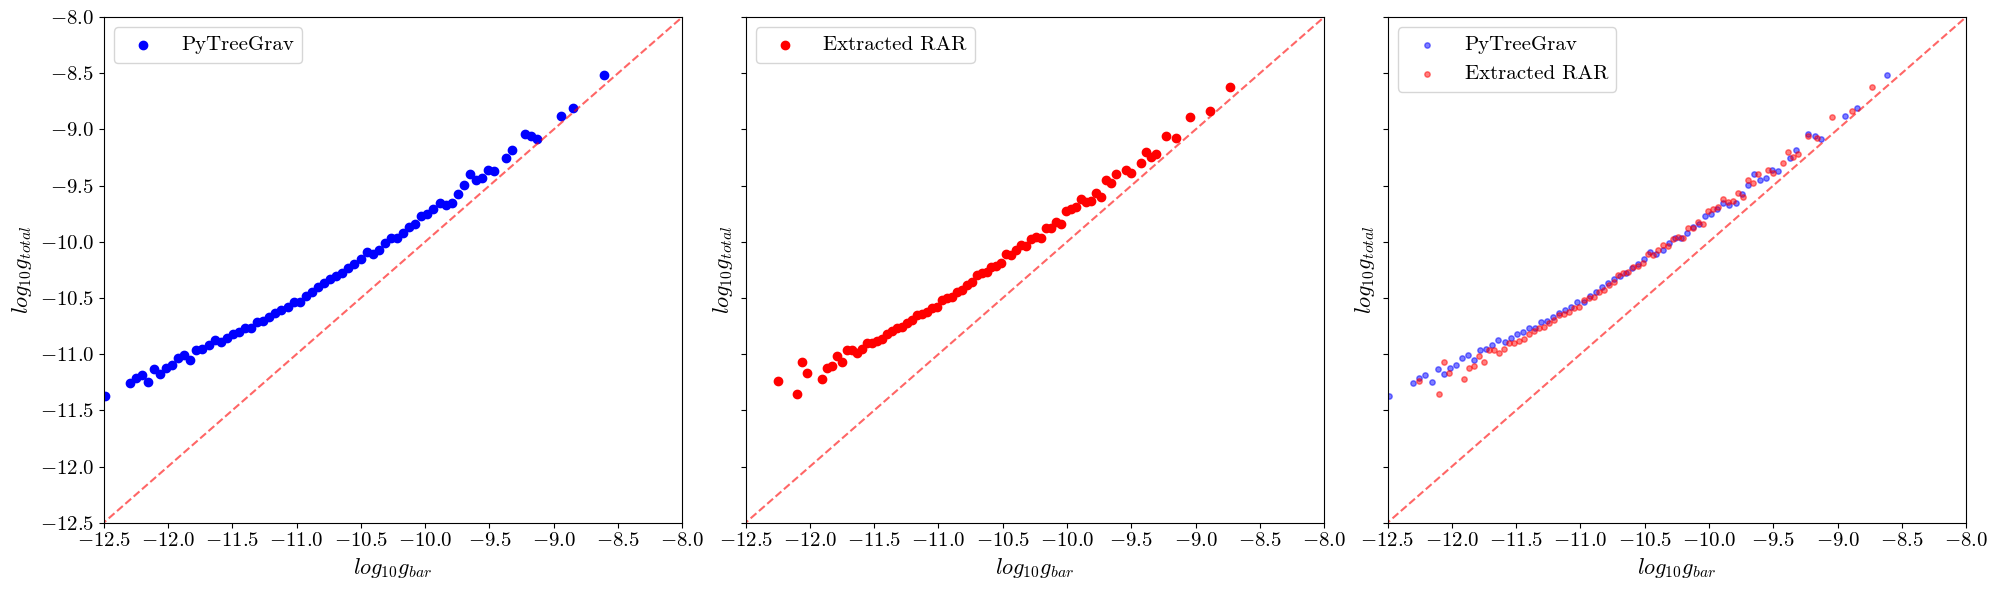

In [18]:
fig, ax = plt.subplots(1, 3, figsize = (20,6), sharey=True, sharex=True)
#plt.suptitle('Comparison of PyTreeGrav and RAR for all galaxies', fontsize = 20)

print(len(g_bar_all_tree))
print(len(g_obs_all))



ax[0].scatter(bincenters, mean, color = 'blue', label = 'PyTreeGrav')
ax[1].scatter(bincenters_tot, mean_tot, color = 'red', label = 'Extracted RAR')
ax[2].scatter(bincenters, mean, color = 'blue', alpha = 0.5, label = 'PyTreeGrav', s = 15)
ax[2].scatter(bincenters_tot, mean_tot, color = 'red', alpha = 0.5, label = 'Extracted RAR', s = 15)


x_fit = np.linspace(-19, -5, 100)
y_fit = x_fit


ax[0].plot(x_fit, y_fit, linestyle = 'dashed', color = 'r', alpha = 0.6)
ax[1].plot(x_fit, y_fit, linestyle = 'dashed', color = 'r', alpha = 0.6)
ax[2].plot(x_fit, y_fit, linestyle = 'dashed', color = 'r', alpha = 0.6)


SPARC_csv = pd.read_csv('/mnt/users/darnej/MPhys/SPARC_RAR.csv', float_precision='round_trip')

SPARC_g_bar = np.array(SPARC_csv.iloc[:, 0])
SPARC_g_obs = np.array(SPARC_csv.iloc[:, 1])
SPARC_std = np.array(SPARC_csv.iloc[:, 2])

#ax[2].errorbar(SPARC_g_bar, SPARC_g_obs, yerr = SPARC_std, fmt = 'o', color = 'black', label = 'SPARC mean')


ax[0].set_xlabel('$log_{10}{g_{bar}}$', fontsize = 16)
ax[0].set_ylabel('$log_{10}{g_{total}}$', fontsize = 16)
ax[0].legend(prop={'size': 15})
ax[1].set_xlabel('$log_{10}{g_{bar}}$', fontsize = 16)
ax[1].set_ylabel('$log_{10}{g_{total}}$', fontsize = 16)
ax[1].legend(prop={'size': 15})
ax[2].set_xlabel('$log_{10}{g_{bar}}$', fontsize = 16)
ax[2].set_ylabel('$log_{10}{g_{total}}$', fontsize = 16)
ax[2].set_xlim(-12.5, -8)
ax[2].set_ylim(-12.5, -8)
ax[2].legend(prop={'size': 15})
plt.tight_layout()
plt.show()

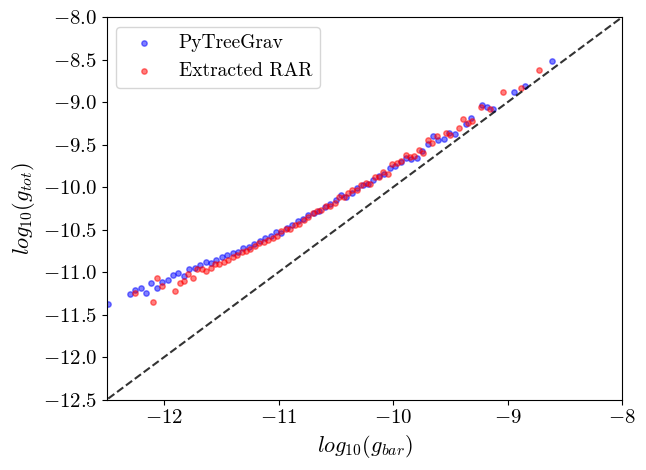

In [19]:

plt.scatter(bincenters, mean, color = 'blue', alpha = 0.5, label = 'PyTreeGrav', s = 15)
plt.scatter(bincenters_tot, mean_tot, color = 'red', alpha = 0.5, label = 'Extracted RAR', s = 15)


x_fit = np.linspace(-19, -5, 100)
y_fit = x_fit

plt.plot(x_fit, y_fit, linestyle = 'dashed', color = 'black', alpha = 0.8)


plt.xlabel('$log_{10}(g_{bar})$', fontsize = 16)
plt.ylabel('$log_{10}(g_{tot})$', fontsize = 16)
plt.legend(prop={'size': 14})
plt.xlim(-12.5, -8)
plt.ylim(-12.5, -8)
plt.tight_layout()
plt.show()

sample: 100%|██████████| 2500/2500 [00:04<00:00, 598.10it/s, 3 steps of size 8.07e-01. acc. prob=0.93]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      1.16      0.02      1.16      1.13      1.19   1825.77      1.00
     sigma      0.13      0.00      0.13      0.13      0.14   1465.15      1.00

Number of divergences: 0


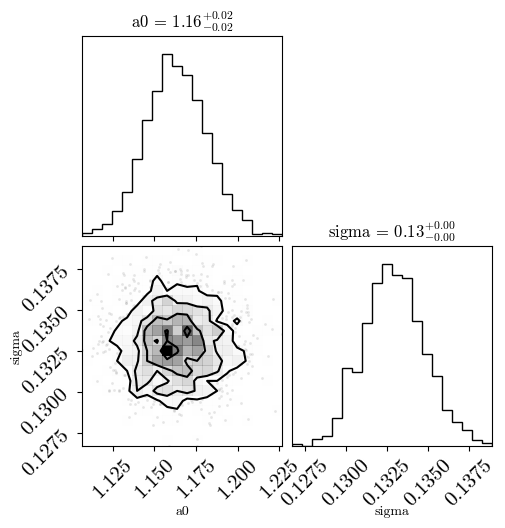

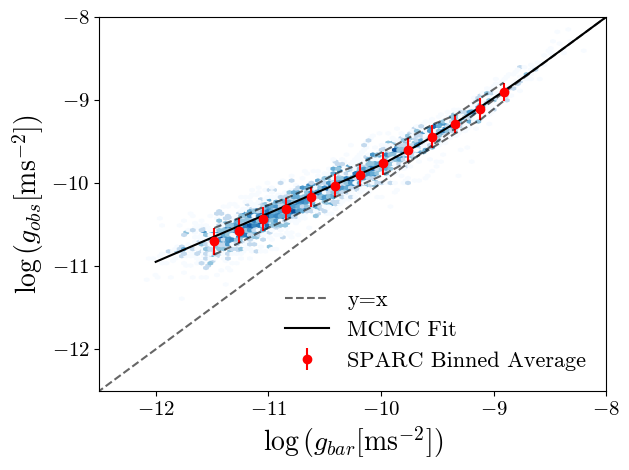

In [20]:
# Read space-separated data
all_SPARC_data = pd.read_csv('/mnt/users/darnej/MPhys/SPARC/SPARC_ALL_DATA_RAR.csv', float_precision='round_trip')

SPARC_all_g_bar_log = np.array(all_SPARC_data.iloc[:, 0])
SPARC_g_bar_error_log = np.array(all_SPARC_data.iloc[:, 1])
SPARC_all_g_obs_log = np.array(all_SPARC_data.iloc[:, 2])
SPARC_g_obs_error_log = np.array(all_SPARC_data.iloc[:, 3])

SPARC_g_bar = 10**SPARC_all_g_bar_log
SPARC_g_obs = 10**SPARC_all_g_obs_log


def model(x=None, y=None):

    a0 = numpyro.sample("a0", dist.Uniform(0, 5))
    sigma = numpyro.sample("sigma", dist.Uniform(0, 5))
    
    # Prediction of y
    log_gobs_pred = jnp.log10(SPARC_g_bar/(1-jnp.exp(-jnp.sqrt(SPARC_g_bar/(a0*1e-10)))))  # Add RAR formula

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(log_gobs_pred, sigma), obs=SPARC_all_g_obs_log)

# Run MCMC
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=2000)
mcmc.run(rng_key_, x=SPARC_g_bar, y=SPARC_all_g_obs_log)

mcmc.print_summary()
samples = mcmc.get_samples()
res = az.from_numpyro(mcmc)

# Extract posterior samples as a NumPy array
samples_array_sparc = np.array([res.posterior[var].values.flatten() for var in res.posterior.keys()]).T


# Corner plot
fig = corner.corner(
    samples_array_sparc,
    labels=list(res.posterior.keys()),  # Ensure correct variable names
    show_titles=True
)
plt.show()

a0_sparc = np.median(samples_array_sparc[:, 0])

#plt.errorbar(SPARC_all_g_bar, SPARC_all_g_obs, yerr = SPARC_g_obs_error, xerr = SPARC_g_bar_error, label = 'SPARC Data', alpha = 0.05)
plt.hexbin(SPARC_all_g_bar_log, SPARC_all_g_obs_log, cmap='Blues', mincnt = 1, bins = 'log')
SPARC_csv = pd.read_csv('/mnt/users/darnej/MPhys/SPARC/SPARC_RAR.csv', float_precision='round_trip')

SPARC_g_bar_mean = np.array(SPARC_csv.iloc[:, 0])
SPARC_g_obs_mean = np.array(SPARC_csv.iloc[:, 1])
SPARC_std_mean = np.array(SPARC_csv.iloc[:, 2])

plt.errorbar(SPARC_g_bar_mean, SPARC_g_obs_mean, yerr = SPARC_std_mean, fmt = 'o', color = 'red', label = 'SPARC Binned Average')

x = np.linspace(-16, -8, 100)
y = x
plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.6, label = 'y=x') 

gbar = np.linspace(1e-8, 1e-12, 100)

plt.plot(np.log10(gbar), np.log10(gbar/(1-np.exp(-np.sqrt(gbar/(a0_sparc*1e-10))))), label = 'MCMC Fit', color = 'black')

plt.plot(SPARC_g_bar_mean, SPARC_g_obs_mean + SPARC_std_mean, linestyle = 'dashed', color = 'black', alpha = 0.6)
plt.plot(SPARC_g_bar_mean, SPARC_g_obs_mean - SPARC_std_mean, linestyle = 'dashed', color = 'black', alpha = 0.6)


plt.xlabel('$\log{(g_{bar}[\mathrm{ms^{-2}}])}$', fontsize = 20)
plt.ylabel('$\log{(g_{obs}[\mathrm{ms^{-2}}])}$', fontsize = 20)
plt.xlim(-12.5, -8)
plt.ylim(-12.5,-8)

plt.tight_layout()
plt.legend(prop={'size': 16}, frameon = False)
plt.show()


sample: 100%|██████████| 2500/2500 [00:04<00:00, 584.93it/s, 3 steps of size 1.09e+00. acc. prob=0.89]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.48      0.02      0.48      0.45      0.50   2050.00      1.00
     sigma      0.21      0.00      0.21      0.20      0.21   2101.71      1.00

Number of divergences: 0


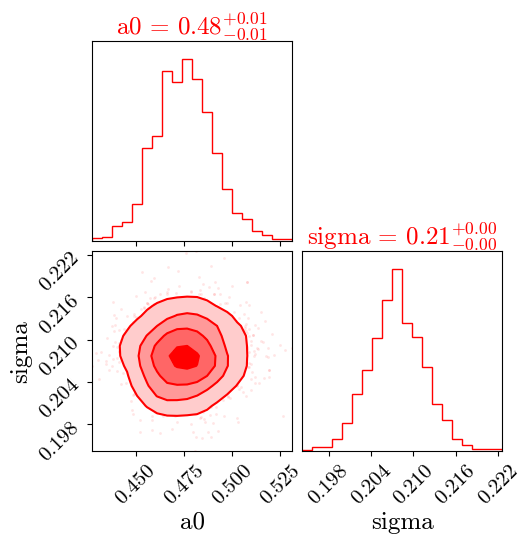

In [21]:
g_obs_plot_all = []
g_bar_tree_plot_all = []

for gal in rar:
    g_obs = rar[gal][1]
    g_bar_tree = pytree_results[gal][0]

    g_bar_tree = g_bar_tree[r_mask]

    mask = (g_obs > 0) & (g_bar_tree > 0)

    g_obs_plot = g_obs[mask]
    g_bar_tree_plot = g_bar_tree[mask]

    g_obs_plot_all = g_obs_plot_all + list(g_obs_plot)
    g_bar_tree_plot_all = g_bar_tree_plot_all + list(g_bar_tree_plot)


g_bar_tree_plot_all = np.array(g_bar_tree_plot_all)
g_obs_plot_all = np.array(g_obs_plot_all)

gbar, gobs = g_bar_tree_plot_all, g_obs_plot_all

log_gbar = jnp.log10(gbar)
log_gobs = jnp.log10(gobs)


def model(x=None, y=None):

    a0 = numpyro.sample("a0", dist.Uniform(0, 5))
    sigma = numpyro.sample("sigma", dist.Uniform(0, 5))
    shape = 1
    
    # Prediction of y
    log_gobs_pred = jnp.log10(gbar*(1-jnp.exp(-(gbar/(a0*1e-10))**(shape/2)))**(-1/shape))    # Add RAR formula

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(log_gobs_pred, sigma), obs=log_gobs)

# Run MCMC
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=2000)
mcmc.run(rng_key_, x=gbar, y=log_gobs)

mcmc.print_summary()
samples = mcmc.get_samples()
res = az.from_numpyro(mcmc)

# Extract posterior samples as a NumPy array
samples_array_mixed = np.array([res.posterior[var].values.flatten() for var in res.posterior.keys()]).T


# Corner plot
fig = corner.corner(
    samples_array_mixed,
    labels=list(res.posterior.keys()),  # Ensure correct variable names
    show_titles=True,
    smooth = 1,
    color = 'red',
    fill_contours=True,
    title_kwargs={"fontsize": 18, "color": "red"},
    label_kwargs={"fontsize": 18}
)
plt.show()


a0 = np.median(samples_array_mixed[:, 0])
shape = 1
sigma_mixed = np.median(samples_array_mixed[:, 1])

g_bar = np.logspace(-8, -14, 40)

log_g_mixed_pred = np.log10(g_bar*(1-np.exp(-(g_bar/(a0*1e-10))**(shape/2)))**(-1/shape))  

/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_1471932/1539140498.py:41: RuntimeWarning: divide by zero encountered in log10
  ax[1].scatter(np.log10(g_bar_tree), np.log10(g_tot_tree), s = 1, alpha = 0.5, c = mean_r)
/tmp/ipykernel_1471932/1539140498.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


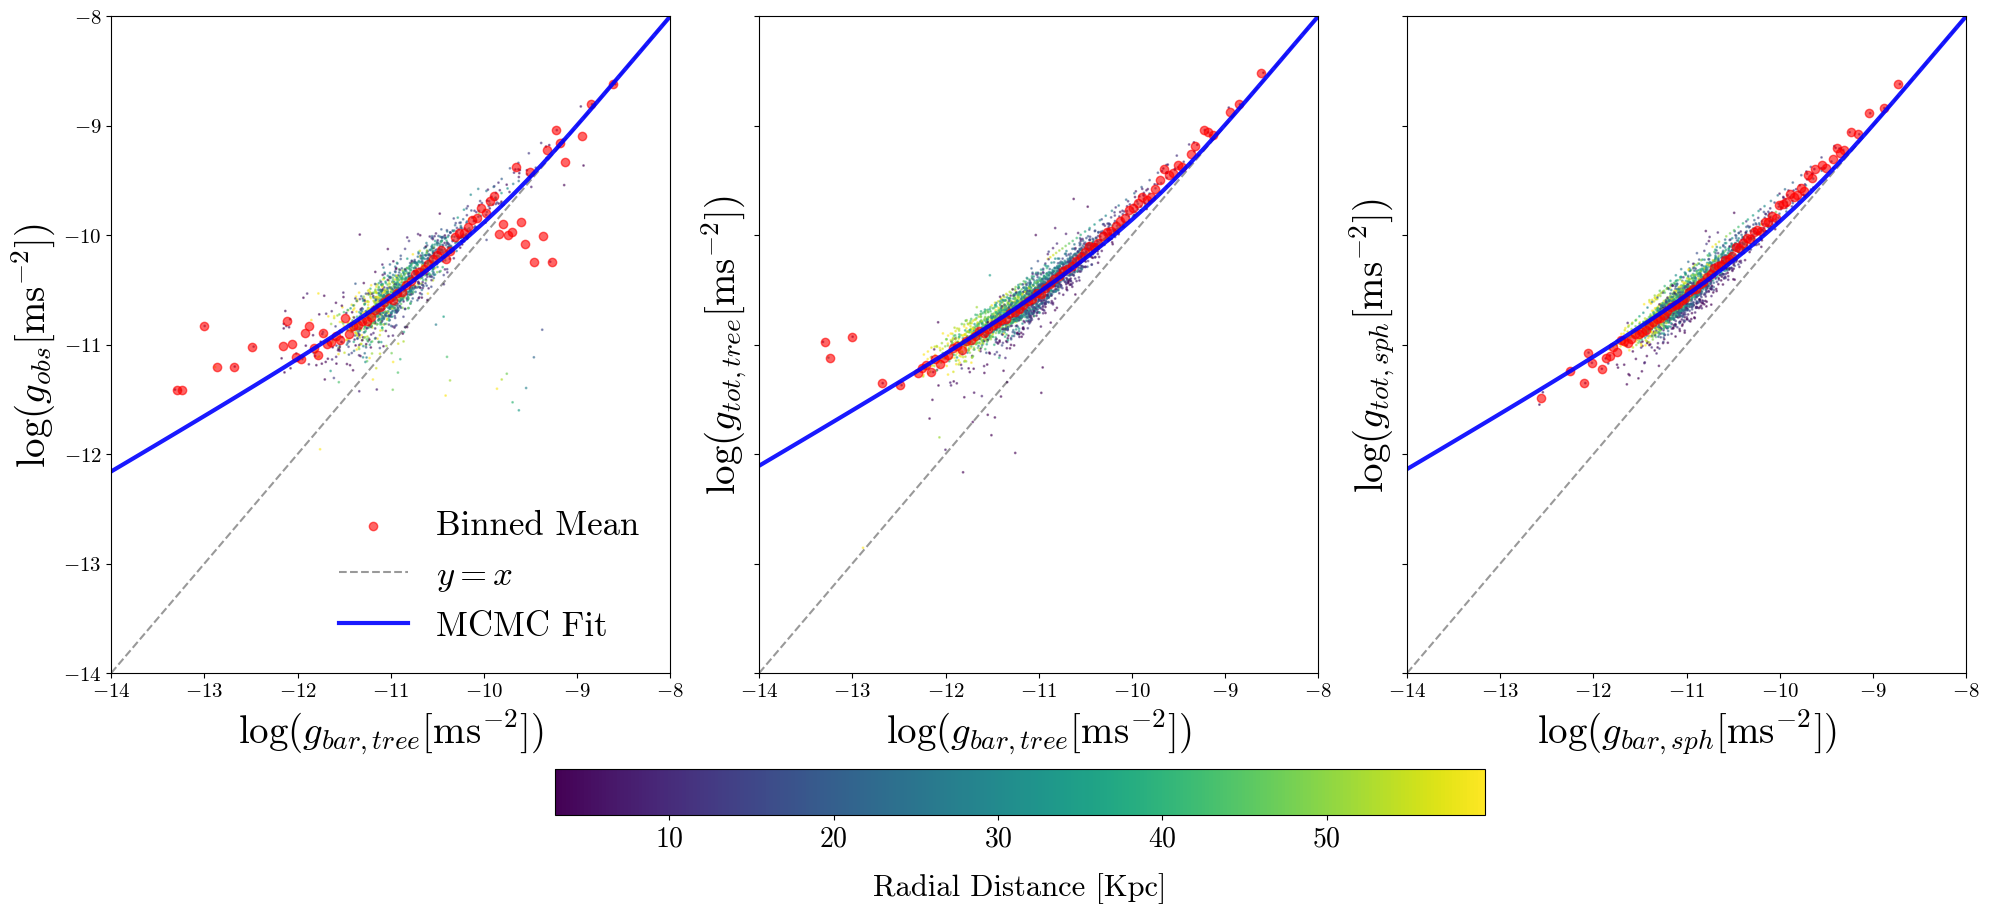

In [22]:
fig, ax = plt.subplots(1, 3, figsize = (20,10), sharey = True, sharex = True)


plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 20  # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 20   # Increase y-axis tick font size

x = np.linspace(-14, -8, 100)
y = x

g_obs_plot_all = []
g_bar_tree_plot_all = []

for gal in rar:

    g_bar = rar[gal][0]
    g_obs = rar[gal][1]
    g_tot = rar[gal][3]

    g_tot_tree = pytree_results[gal][1]
    g_bar_tree = pytree_results[gal][0]
    mean_r = pytree_results[gal][2]

    g_bar_tree = g_bar_tree[r_mask]
    mean_r = mean_r[r_mask]
    g_tot_tree = g_tot_tree[r_mask]

    mask = (g_obs > 0) & (g_bar_tree > 0)

    g_obs_plot = g_obs[mask]
    g_bar_tree_plot = g_bar_tree[mask]
    mean_r_plot = mean_r[mask]

    g_obs_plot_all = g_obs_plot_all + list(g_obs_plot)
    g_bar_tree_plot_all = g_bar_tree_plot_all + list(g_bar_tree_plot)

    ax[0].scatter(np.log10(g_bar_tree_plot), np.log10(g_obs_plot), s = 1, alpha = 0.5, c = mean_r_plot)
    ax[2].scatter(np.log10(g_bar), np.log10(g_tot), s = 1, alpha = 0.5, c = rar[gal][2])
    ax[1].scatter(np.log10(g_bar_tree), np.log10(g_tot_tree), s = 1, alpha = 0.5, c = mean_r)



mean_mixed, bins_mixed, bin_number = stats.binned_statistic(np.log10(g_bar_tree_plot_all), np.log10(g_obs_plot_all), bins=100, statistic='mean')

bincenters_mixed = 0.5*(bins_mixed[1:]+bins_mixed[:-1])


ax[0].scatter(bincenters_mixed, mean_mixed, color = 'red', alpha = 0.6, label = 'Binned Mean')
ax[0].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4, label='$y=x$')
ax[0].set_xlabel('$\log({g_{bar,tree}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[0].set_ylabel('$\log({g_{obs}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[0].set_xlim(-14, -8)
ax[0].set_ylim(-14,-8)

ax[2].scatter(bincenters_tot, mean_tot, color = 'red', alpha = 0.6)
ax[2].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4)
ax[2].set_xlabel('$\log({g_{bar,sph}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[2].set_ylabel('$\log({g_{tot,sph}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[2].set_xlim(-14, -8)
ax[2].set_ylim(-14,-8)

ax[1].scatter(bincenters, mean, color = 'red', alpha = 0.6)
ax[1].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4)
ax[1].set_xlabel('$\log({g_{bar,tree}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[1].set_ylabel('$\log({g_{tot,tree}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[1].set_xlim(-14, -8)
ax[1].set_ylim(-14,-8)


colors = rar[1][2]
points = np.array([np.log10(rar[1][0]), np.log10(rar[1][1])]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(np.array(colors).min(), np.array(colors).max())
lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
lc.set_array(colors)

cbar = fig.colorbar(lc, ax=ax[:], location = 'bottom', shrink = 0.6, pad = -0.44)
cbar.set_label("Radial Distance [Kpc]", labelpad=15, fontsize = 22)




g_bar = np.logspace(-8, -14, 40)

ax[0].plot(np.log10(g_bar), log_g_mixed_pred, color='blue', linewidth = 3, alpha = 0.9, label = "MCMC Fit")

ax[2].plot(np.log10(g_bar), log_g_tot_pred, color='blue', linewidth = 3, alpha = 0.9)

ax[1].plot(np.log10(g_bar), log_g_tot_pred_pytree, color='blue', linewidth = 3, alpha = 0.9)

plt.tight_layout()
ax[0].legend(prop={'size': 25}, loc = 'lower right', frameon = False, fontsize = 30)
plt.show()

['/mnt/users/darnej/MPhys/samples_53_scatter_EFE0_rar.npy', '/mnt/users/darnej/MPhys/labels_53_scatter_EFE0_rar.npy']


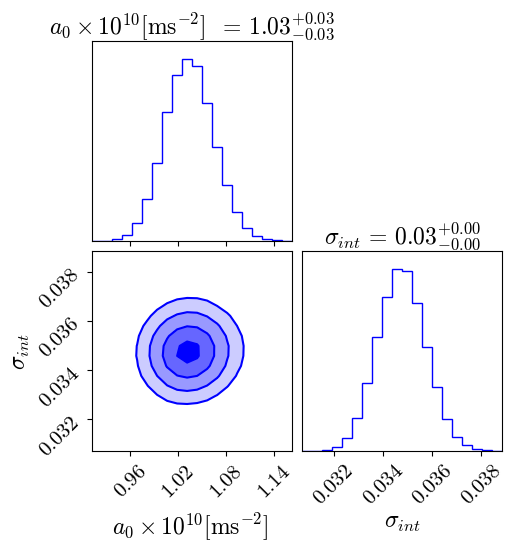

In [23]:
#OBSERVED SPARC SCATTER


plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size


directory = '/mnt/users/darnej/MPhys/'

files = glob.glob(os.path.join(directory, '*.npy'))

print(files)

samples = files[0]
labels = files[1]

labels = np.load(labels)

samples = np.load(samples)

a0_index = np.where(labels == 'a0')[0][0]

scatter_index = np.where(labels == 'scatter')[0][0]

a0 = samples[:, a0_index]

scatter = samples[:, scatter_index]

samples_SPARC = np.column_stack((a0, scatter))

fig = corner.corner(samples_SPARC, 
                      labels=[r'$a_0 \times 10^{10} [\mathrm{ms^{-2}}]$ ', '$\sigma_{int}$'],
                      show_titles=True,
                      title_kwargs={"fontsize": 17}, 
                      label_kwargs={"fontsize": 17},
                      fill_contours=True,
                      color='blue',
                      plot_datapoints=False,
                      smooth = 1)

plt.show()


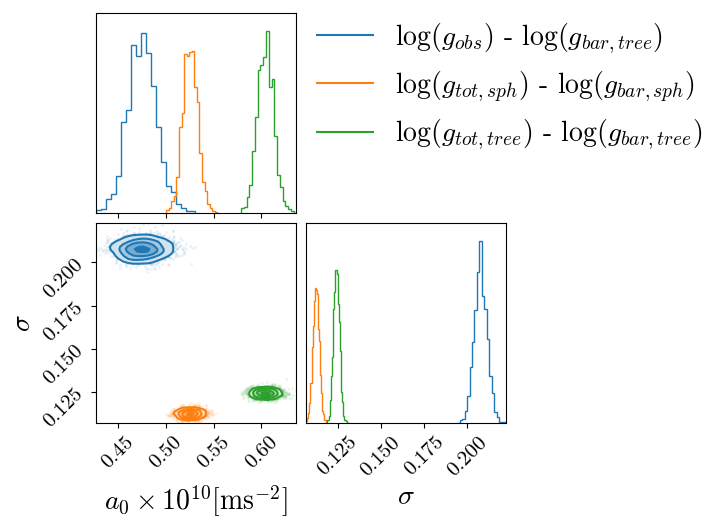

sigma_mixed: 0.20758260786533356
sigma_tot: 0.1123390942811966
sigma_pytree: 0.12427087128162384


In [24]:
import matplotlib.lines as mlines
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size

sample_labels = ['$\log({g_{obs}})$ - $\log({g_{bar,tree}})$',
                '$\log({g_{tot,sph}})$ - $\log({g_{bar,sph}})$',
                '$\log({g_{tot,tree}})$ - $\log({g_{bar,tree}})$']

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig = corner.corner(samples_array_mixed, labels = [r'$a_0 \times 10^{10}$', '$\sigma$'], label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[0], smooth = 1)

fig = corner.corner(samples_array_tot, labels = [r'$a_0 \times 10^{10}$', '$\sigma$'], label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[1], smooth = 1, fig = fig)

fig = corner.corner(samples_array, labels = [r'$a_0 \times 10^{10} [\mathrm{ms^{-2}}]$', '$\sigma$'], label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[2], smooth = 1, fig = fig)

plt.legend(handles=[
    mlines.Line2D([], [], color = colors[i], label=sample_labels[i])
    for i in range(3)], fontsize=20, frameon=False, loc = (0.,1.3)
)


plt.show()

print(f'sigma_mixed: {sigma_mixed}')
print(f'sigma_tot: {sigma_tot}')
print(f'sigma_pytree: {sigma_pytree}')

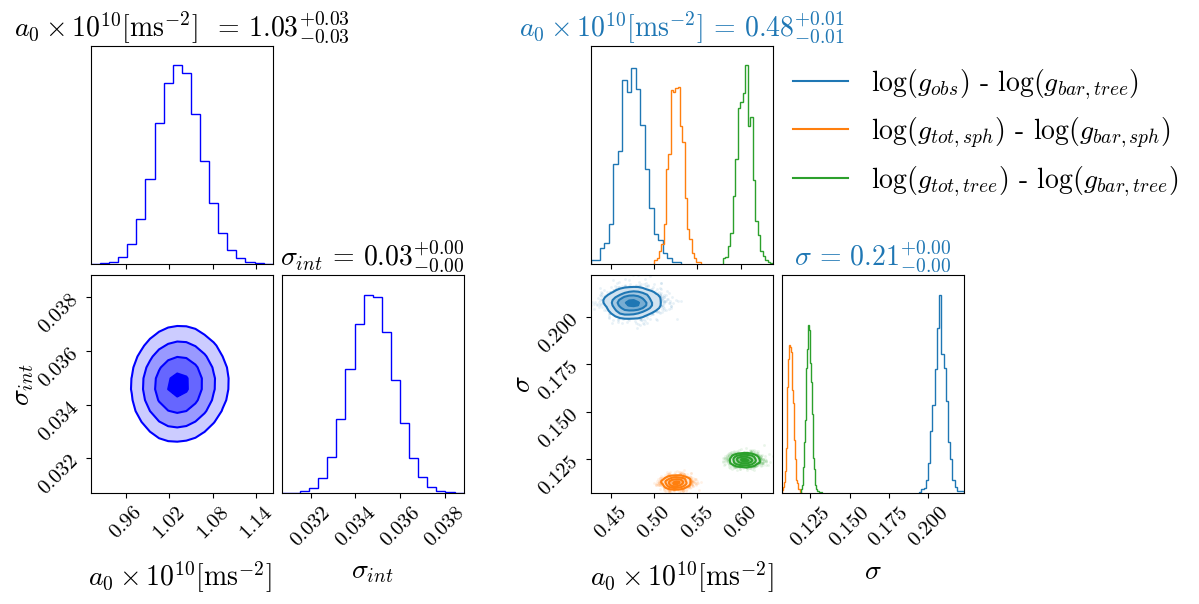

In [25]:

import matplotlib.lines as mlines
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size


directory = '/mnt/users/darnej/MPhys/'

files = glob.glob(os.path.join(directory, '*.npy'))

samples = files[0]
labels = files[1]

labels = np.load(labels)

samples = np.load(samples)

a0_index = np.where(labels == 'a0')[0][0]

scatter_index = np.where(labels == 'scatter')[0][0]

a0 = samples[:, a0_index]

scatter = samples[:, scatter_index]

samples_SPARC = np.column_stack((a0, scatter))

fig = plt.figure(figsize=(10, 6))
subfigs = fig.subfigures(1, 2)


fig1 = corner.corner(samples_SPARC, 
                      labels=[r'$a_0 \times 10^{10} [\mathrm{ms^{-2}}]$ ', '$\sigma_{int}$'],
                      show_titles=True,
                      title_kwargs={"fontsize": 20, 'color': 'black'}, 
                      label_kwargs={"fontsize": 20},
                      fill_contours=True,
                      color='blue',
                      plot_datapoints=False,
                      smooth = 1,
                      fig = subfigs[0])


sample_labels = ['$\log({g_{obs}})$ - $\log({g_{bar,tree}})$',
                '$\log({g_{tot,sph}})$ - $\log({g_{bar,sph}})$',
                '$\log({g_{tot,tree}})$ - $\log({g_{bar,tree}})$']

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']



fig2 = corner.corner(samples_array_mixed, labels = [r'$a_0 \times 10^{10}[\mathrm{ms^{-2}}]$', '$\sigma$'], show_titles = True, title_kwargs={"fontsize": 20, "color": colors[0]}, label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[0], smooth = 1, fig = subfigs[1])

fig2 = corner.corner(samples_array_tot, labels = [r'$a_0 \times 10^{10}$', '$\sigma$'], label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[1], smooth = 1, fig = subfigs[1])

fig2 = corner.corner(samples_array, labels = [r'$a_0 \times 10^{10} [\mathrm{ms^{-2}}]$', '$\sigma$'], label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[2], smooth = 1, fig = subfigs[1])

plt.legend(handles=[
    mlines.Line2D([], [], color = colors[i], label=sample_labels[i])
    for i in range(3)], fontsize=20, frameon=False, loc = (0.,1.3)
)


plt.show()

In [26]:

import numpy as np
from scipy.spatial.distance import mahalanobis

# Compute sample means (NOT medians)
mean_obs = np.mean(samples_array_mixed, axis=0)
mean_SPARC = np.mean(samples_SPARC, axis=0)

# Compute individual covariances
cov_obs = np.cov(samples_array_mixed, rowvar=False)
cov_SPARC = np.cov(samples_SPARC, rowvar=False)

# Pooled covariance = sum of covariances
cov_pooled = cov_obs + cov_SPARC

# Inverse of pooled covariance
inv_cov_pooled = np.linalg.pinv(cov_pooled)  # using pinv for safety

# Mahalanobis distance
dist = mahalanobis(mean_obs, mean_SPARC, inv_cov_pooled)

print('Mahalanobis distance:', dist)

Mahalanobis distance: 47.01434578547387


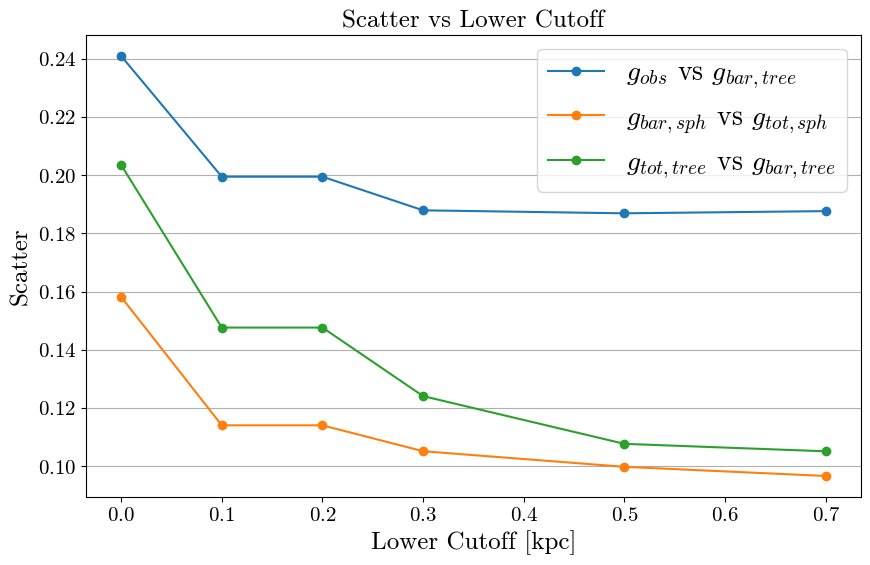

In [27]:
#PLOTTING SCATTERS FOR DIFFERENT LOWER CUTOFF


Lower_cutoff = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]



mixed_scatter = [0.24096015095710754, 0.19947007298469543, 0.19947007298469543, 0.1879209727048874, 0.18689820170402527, 0.1876508891582489]
tot_sph_scatter = [0.15814882516860962, 0.11404423415660858, 0.11404423415660858, 0.1051531583070755, 0.09978727251291275, 0.09664586186408997]
tot_tree_scatter = [0.20354029536247253, 0.1476411521434784, 0.14763417840003967, 0.1240851879119873, 0.10768517851829529, 0.10512233525514603]


plt.figure(figsize=(10, 6))
plt.plot(Lower_cutoff, mixed_scatter, marker='o', label='$g_{obs}$ vs $g_{bar,tree}$')
plt.plot(Lower_cutoff, tot_sph_scatter, marker='o', label='$g_{bar,sph}$ vs $g_{tot,sph}$')
plt.plot(Lower_cutoff, tot_tree_scatter, marker='o', label='$g_{tot,tree}$ vs $g_{bar,tree}$')
plt.xlabel('Lower Cutoff [kpc]', fontsize=18)
plt.ylabel('Scatter', fontsize=18)
plt.title('Scatter vs Lower Cutoff', fontsize=18)
plt.legend(prop={'size': 20}, frameon = True)
plt.grid(axis = 'y')
plt.show()
